# VGG-16: feature extractor y fine-tuning (CIFAR-10)

## Configuración y datos

In [6]:
%pip install certifi
import os, certifi
os.environ["SSL_CERT_FILE"] = certifi.where()


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import copy
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import vgg16, VGG16_Weights
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"torch {torch.__version__} | device: {device}")
Path("models").mkdir(exist_ok=True)

torch 2.14.1 | device: mps


In [2]:
train_raw = datasets.CIFAR10(root="data", train=True, download=True)
y_train = np.array(train_raw.targets)
CLASSES = train_raw.classes

# Mismo split 45,000 / 5,000 que el resto del equipo 
if Path("split_indices.npz").exists():
    s = np.load("split_indices.npz")
    idx_train, idx_val = s["train"], s["val"]
    idx_train_small = s["train_small"] if "train_small" in s.files else None
else:
    idx_train, idx_val = train_test_split(
        np.arange(len(y_train)), test_size=5_000, stratify=y_train, random_state=SEED
    )
    idx_train_small = None
print(f"train: {len(idx_train):,} | val: {len(idx_val):,}")

VGG_RES = 128   # misma resolución para feature extractor y fine-tuning 
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
resize = transforms.Resize((VGG_RES, VGG_RES))

eval_tf = transforms.Compose([resize, transforms.ToTensor(), norm])
train_tf_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    resize, transforms.ToTensor(), norm,
])

def make_datasets(train_tf):
    full_train = datasets.CIFAR10("data", train=True, download=False, transform=train_tf)
    full_eval = datasets.CIFAR10("data", train=True, download=False, transform=eval_tf)
    return {"train": Subset(full_train, idx_train), "val": Subset(full_eval, idx_val)}

DSETS = {True: make_datasets(train_tf_aug), False: make_datasets(eval_tf)} 

def make_loaders(augment, batch_size):
    d = DSETS[augment]
    return (
        DataLoader(d["train"], batch_size=batch_size, shuffle=True, num_workers=0),
        DataLoader(d["val"], batch_size=128, shuffle=False, num_workers=0),
    )

100%|██████████| 170M/170M [00:34<00:00, 4.94MB/s] 


train: 45,000 | val: 5,000


Pasar de 32×32 a 128×128 multiplica los píxeles por 16, y el costo de las convoluciones escala casi linealmente con los píxeles. A 128 px el backbone produce un mapa de 512×4×4; avgpool lo reescala a 7×7 para que las dimensiones del clasificador preentrenado sigan siendo válidas. 

## Construcción de los modelos
VGG-16 con pesos IMAGENET1K_V1. model.features agrupa las 13 convoluciones en 5 bloques; cada bloque termina en un MaxPool2d. La última capa del clasificador se reemplaza por Linear(4096, 10).

| Bloque | Índices en model.features |
|---|---|
| 1 | 0–4 |
| 2 | 5–9 |
| 3 | 10–16 |
| 4 | 17–23 |
| 5 | 24–30 |

In [6]:
BLOCK_RANGES = {1: (0, 5), 2: (5, 10), 3: (10, 17), 4: (17, 24), 5: (24, 31)}  

def build_vgg16(unfrozen=(), n_classes=10):
    """VGG-16 preentrenada. unfrozen=() -> feature extractor; unfrozen=(5,) o (4, 5) -> fine-tuning.
    El clasificador siempre se entrena."""
    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

    model.avgpool = nn.Upsample(size=(7, 7), mode="bilinear", align_corners=False)
    model.classifier[6] = nn.Linear(4096, n_classes)      
    for p in model.parameters():                          # congelar todo
        p.requires_grad = False
    for b in unfrozen:                                    # descongelar bloques elegidos
        lo, hi = BLOCK_RANGES[b]
        for p in model.features[lo:hi].parameters():
            p.requires_grad = True
    for p in model.classifier.parameters():               # el clasificador siempre se entrena
        p.requires_grad = True
    return model

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def block_params(model):
    return {b: sum(p.numel() for p in model.features[lo:hi].parameters())
            for b, (lo, hi) in BLOCK_RANGES.items()}

m = build_vgg16(unfrozen=())
total, trainable = count_params(m)
print(f"Feature extractor -> totales: {total:,} | entrenables: {trainable:,}")
print("Parámetros por bloque:", block_params(m))
print("Clasificador:", m.classifier)
assert total == 134_301_514 and trainable == 119_586_826   # valores esperados 

m = build_vgg16(unfrozen=(4, 5))
print("Fine-tuning bloques 4 y 5 -> entrenables:", f"{count_params(m)[1]:,}")
del m

Feature extractor -> totales: 134,301,514 | entrenables: 119,586,826
Parámetros por bloque: {1: 38720, 2: 221440, 3: 1475328, 4: 5899776, 5: 7079424}
Clasificador: Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=10, bias=True)
)
Fine-tuning bloques 4 y 5 -> entrenables: 132,566,026


## Utilidades de entrenamiento y medición

In [7]:
def sync():
    if device == "cuda": torch.cuda.synchronize()
    elif device == "mps": torch.mps.synchronize()

def mem_now():
    if device == "mps": return torch.mps.current_allocated_memory()
    if device == "cuda": return torch.cuda.memory_allocated()
    return 0

def mem_reset():
    if device == "cuda": torch.cuda.reset_peak_memory_stats()

def mem_peak_mb(sampled_peak):
    if device == "cuda": return torch.cuda.max_memory_allocated() / 2**20
    if device == "mps": return sampled_peak / 2**20   
    return float("nan")

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, preds, labels = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss_sum += criterion(out, y).item() * x.size(0)
        preds.append(out.argmax(1).cpu()); labels.append(y.cpu())
    preds, labels = torch.cat(preds).numpy(), torch.cat(labels).numpy()
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"loss": loss_sum / len(labels), "acc": accuracy_score(labels, preds),
            "precision": p, "recall": r, "f1": f1}

def build_optimizer(model, cfg):
    """Dos param_groups: clasificador (lr_head) y, si hay bloques descongelados, backbone (lr_backbone)."""
    head = [p for p in model.classifier.parameters() if p.requires_grad]
    backbone = [p for p in model.features.parameters() if p.requires_grad]
    groups = [{"params": head, "lr": cfg["lr_head"]}]
    if backbone:
        groups.append({"params": backbone, "lr": cfg["lr_backbone"]})
    if cfg["opt"] == "adam":
        return torch.optim.Adam(groups, weight_decay=cfg["wd"])
    if cfg["opt"] == "adamw":
        return torch.optim.AdamW(groups, weight_decay=cfg["wd"])
    if cfg["opt"] == "sgd":
        return torch.optim.SGD(groups, weight_decay=cfg["wd"], momentum=0.9, nesterov=True)
    raise ValueError(cfg["opt"])

def trainable_state(model):
    names = {n for n, p in model.named_parameters() if p.requires_grad}
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items() if k in names}

def frozen_desc(cfg):
    ub = set(cfg["unfrozen"])
    frozen = [b for b in range(1, 6) if b not in ub]
    fro = "bloques " + ",".join(map(str, frozen)) if frozen else "ninguno"
    return f"features: {fro} congelados | clasificador entrenable"

def run_experiment(name, cfg, verbose=True):
    set_seed()
    train_loader, val_loader = make_loaders(cfg["augment"], cfg["batch_size"])
    model = build_vgg16(unfrozen=cfg["unfrozen"]).to(device)
    total_p, trainable_p = count_params(model)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, cfg)
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
                 if cfg["sched"] == "cosine" else None)

    hist = {k: [] for k in ["train_loss", "val_loss", "val_acc", "val_precision",
                            "val_recall", "val_f1", "epoch_time", "cum_time"]}
    best = {"acc": -1.0}
    peak, t_start = 0, time.time()
    mem_reset()

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()   
        sync(); t0 = time.time()
        loss_sum, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            out = model(x)
            peak = max(peak, mem_now())         
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            peak = max(peak, mem_now())         
            loss_sum += loss.item() * x.size(0); n += x.size(0)
        sync(); epoch_time = time.time() - t0
        if scheduler: scheduler.step()

        m = evaluate(model, val_loader, criterion)
        hist["train_loss"].append(loss_sum / n)
        hist["val_loss"].append(m["loss"])
        hist["val_acc"].append(m["acc"])
        hist["val_precision"].append(m["precision"])
        hist["val_recall"].append(m["recall"])
        hist["val_f1"].append(m["f1"])
        hist["epoch_time"].append(epoch_time)
        hist["cum_time"].append(time.time() - t_start)

        if m["acc"] > best["acc"]:
            best = {**m, "epoch": epoch, "time_to_best": hist["cum_time"][-1],
                    "state": trainable_state(model)}
        if verbose:
            print(f"[{name}] ep {epoch:02d}/{cfg['epochs']} | train {hist['train_loss'][-1]:.4f} "
                  f"| val {m['loss']:.4f} | acc {m['acc']:.4f} | f1 {m['f1']:.4f} | {epoch_time:.1f}s")

    total_time = time.time() - t_start
    torch.save(best["state"], f"models/vgg_{name}.pt")  
    del model, optimizer
    return {
        "name": name, "kind": "feature_extractor" if not cfg["unfrozen"] else "fine_tuning",
        "config": cfg, "frozen": frozen_desc(cfg), "history": hist,
        "params_total": total_p, "params_trainable": trainable_p,
        "best_epoch": best["epoch"], "time_to_best": best["time_to_best"],
        "val_best": {k: float(best[k]) for k in ["loss", "acc", "precision", "recall", "f1"]},
        "mean_epoch_time": float(np.mean(hist["epoch_time"])),
        "total_time": total_time, "peak_mem_mb": mem_peak_mb(peak),
        "device": device, "resolution": VGG_RES,
    }

## Prueba de velocidad

In [8]:
def bench(unfrozen, n_batches=10):
    set_seed()
    model = build_vgg16(unfrozen=unfrozen).to(device).train()
    opt = build_optimizer(model, dict(opt="adamw", lr_head=1e-4, lr_backbone=1e-5, wd=1e-2))
    crit = nn.CrossEntropyLoss()
    loader, _ = make_loaders(True, 64)
    it = iter(loader)
    for i in range(n_batches + 2):              # 2 batches de calentamiento
        x, y = next(it); x, y = x.to(device), y.to(device)
        if i == 2: sync(); t0 = time.time()
        opt.zero_grad(set_to_none=True); crit(model(x), y).backward(); opt.step()
    sync(); dt = (time.time() - t0) / n_batches
    print(f"unfrozen={unfrozen}: {dt:.2f} s/batch -> ~{dt * len(idx_train) / 64:.0f} s/epoch")
    del model, opt

for u in [(), (5,), (4, 5), (3, 4, 5)]:
    bench(u)

unfrozen=(): 0.25 s/batch -> ~174 s/epoch
unfrozen=(5,): 0.28 s/batch -> ~194 s/epoch
unfrozen=(4, 5): 0.36 s/batch -> ~253 s/epoch
unfrozen=(3, 4, 5): 0.47 s/batch -> ~330 s/epoch


## 3. Iteraciones
Feature extractor (bloques 1–5 congelados; se entrena sólo el clasificador) y fine-tuning (clasificador + bloques superiores con lr_backbone < lr_head, vía param_groups).

| # | Nombre | Qué cambia |
|---|--------|-----------|
| FE-1 | fe_adam | Línea base: Adam, lr 1e-4, sin scheduler |
| FE-2 | fe_adamw_cosine | AdamW (wd 1e-2) + cosine, lr 3e-4 |
| FE-3 | fe_sgd_cosine | SGD con momentum + cosine |
| FE-4 | fe_sin_aug | Igual que FE-2 sin data augmentation (ablación) |
| FT-1 | ft_b5 | Descongela bloque 5; lr backbone 1e-5 |
| FT-2 | ft_b4b5 | Descongela bloques 4 y 5; lr backbone 1e-5 |
| FT-3 | ft_b3b4b5 | Descongela bloques 3, 4 y 5 |
| FT-4 | ft_b4b5_lr_alto | Bloques 4 y 5 con lr backbone 1e-4 (igual que la cabeza): prueba de olvido catastrófico |

In [9]:
def cfg(unfrozen, opt, lr_head, lr_backbone=None, wd=0.0, sched=None, epochs=8, batch_size=64, augment=True):
    return dict(unfrozen=tuple(unfrozen), opt=opt, lr_head=lr_head, lr_backbone=lr_backbone,
                wd=wd, sched=sched, epochs=epochs, batch_size=batch_size, augment=augment)

CONFIGS = {
    # --- Feature extractor ---
    "fe_adam":         cfg((),  "adam",  1e-4, epochs=8),
    "fe_adamw_cosine": cfg((),  "adamw", 3e-4, wd=1e-2, sched="cosine", epochs=10),
    "fe_sgd_cosine":   cfg((),  "sgd",   1e-2, wd=5e-4, sched="cosine", epochs=10),
    "fe_sin_aug":      cfg((),  "adamw", 3e-4, wd=1e-2, sched="cosine", epochs=10, augment=False),
    # --- Fine-tuning ---
    "ft_b5":           cfg((5,),       "adamw", 1e-4, 1e-5, wd=1e-2, sched="cosine", epochs=8),
    "ft_b4b5":         cfg((4, 5),     "adamw", 1e-4, 1e-5, wd=1e-2, sched="cosine", epochs=8),
    "ft_b3b4b5":       cfg((3, 4, 5),  "adamw", 1e-4, 1e-5, wd=1e-2, sched="cosine", epochs=8),
    "ft_b4b5_lr_alto": cfg((4, 5),     "adamw", 1e-4, 1e-4, wd=1e-2, sched="cosine", epochs=8),
}
RESULTS = {}

### Iteración FE-1: fe_adam

In [10]:
RESULTS["fe_adam"] = run_experiment("fe_adam", CONFIGS["fe_adam"])

[fe_adam] ep 01/8 | train 0.6057 | val 0.3832 | acc 0.8646 | f1 0.8642 | 188.1s
[fe_adam] ep 02/8 | train 0.4612 | val 0.3642 | acc 0.8670 | f1 0.8659 | 196.4s
[fe_adam] ep 03/8 | train 0.4144 | val 0.3546 | acc 0.8784 | f1 0.8779 | 189.9s
[fe_adam] ep 04/8 | train 0.3862 | val 0.3462 | acc 0.8778 | f1 0.8779 | 185.9s
[fe_adam] ep 05/8 | train 0.3643 | val 0.3300 | acc 0.8848 | f1 0.8849 | 184.6s
[fe_adam] ep 06/8 | train 0.3413 | val 0.3215 | acc 0.8868 | f1 0.8862 | 184.4s
[fe_adam] ep 07/8 | train 0.3225 | val 0.3179 | acc 0.8892 | f1 0.8895 | 187.6s
[fe_adam] ep 08/8 | train 0.3163 | val 0.3196 | acc 0.8928 | f1 0.8927 | 183.8s


### Iteración FE-2: fe_adamw_cosine

In [11]:
RESULTS["fe_adamw_cosine"] = run_experiment("fe_adamw_cosine", CONFIGS["fe_adamw_cosine"])

[fe_adamw_cosine] ep 01/10 | train 0.6543 | val 0.4407 | acc 0.8508 | f1 0.8512 | 201.1s
[fe_adamw_cosine] ep 02/10 | train 0.5222 | val 0.3911 | acc 0.8654 | f1 0.8647 | 189.3s
[fe_adamw_cosine] ep 03/10 | train 0.4690 | val 0.3908 | acc 0.8696 | f1 0.8694 | 187.9s
[fe_adamw_cosine] ep 04/10 | train 0.4324 | val 0.3722 | acc 0.8732 | f1 0.8737 | 187.3s
[fe_adamw_cosine] ep 05/10 | train 0.3914 | val 0.3454 | acc 0.8796 | f1 0.8798 | 188.2s
[fe_adamw_cosine] ep 06/10 | train 0.3536 | val 0.3386 | acc 0.8858 | f1 0.8853 | 188.1s
[fe_adamw_cosine] ep 07/10 | train 0.3180 | val 0.3107 | acc 0.8944 | f1 0.8946 | 187.2s
[fe_adamw_cosine] ep 08/10 | train 0.2944 | val 0.3069 | acc 0.8952 | f1 0.8955 | 187.2s
[fe_adamw_cosine] ep 09/10 | train 0.2693 | val 0.3015 | acc 0.8962 | f1 0.8963 | 186.8s
[fe_adamw_cosine] ep 10/10 | train 0.2557 | val 0.2996 | acc 0.8972 | f1 0.8973 | 191.0s


### Iteración FE-3: fe_sgd_cosine

In [12]:
RESULTS["fe_sgd_cosine"] = run_experiment("fe_sgd_cosine", CONFIGS["fe_sgd_cosine"])

[fe_sgd_cosine] ep 01/10 | train 0.6886 | val 0.4666 | acc 0.8424 | f1 0.8421 | 176.4s
[fe_sgd_cosine] ep 02/10 | train 0.5456 | val 0.3981 | acc 0.8624 | f1 0.8611 | 178.7s
[fe_sgd_cosine] ep 03/10 | train 0.4875 | val 0.4092 | acc 0.8644 | f1 0.8639 | 175.6s
[fe_sgd_cosine] ep 04/10 | train 0.4396 | val 0.3755 | acc 0.8680 | f1 0.8674 | 176.3s
[fe_sgd_cosine] ep 05/10 | train 0.3973 | val 0.3480 | acc 0.8830 | f1 0.8827 | 400.1s
[fe_sgd_cosine] ep 06/10 | train 0.3640 | val 0.3301 | acc 0.8872 | f1 0.8866 | 178.2s
[fe_sgd_cosine] ep 07/10 | train 0.3243 | val 0.3113 | acc 0.8956 | f1 0.8956 | 175.3s
[fe_sgd_cosine] ep 08/10 | train 0.3040 | val 0.3061 | acc 0.8938 | f1 0.8939 | 173.6s
[fe_sgd_cosine] ep 09/10 | train 0.2802 | val 0.3035 | acc 0.8922 | f1 0.8922 | 174.7s
[fe_sgd_cosine] ep 10/10 | train 0.2680 | val 0.3006 | acc 0.8944 | f1 0.8945 | 174.0s


### Iteración FE-4: fe_sin_aug

In [13]:
RESULTS["fe_sin_aug"] = run_experiment("fe_sin_aug", CONFIGS["fe_sin_aug"])

[fe_sin_aug] ep 01/10 | train 0.5525 | val 0.4023 | acc 0.8602 | f1 0.8598 | 191.8s
[fe_sin_aug] ep 02/10 | train 0.3671 | val 0.3667 | acc 0.8774 | f1 0.8777 | 191.3s
[fe_sin_aug] ep 03/10 | train 0.2663 | val 0.3613 | acc 0.8842 | f1 0.8839 | 186.7s
[fe_sin_aug] ep 04/10 | train 0.1964 | val 0.3840 | acc 0.8836 | f1 0.8839 | 187.1s
[fe_sin_aug] ep 05/10 | train 0.1261 | val 0.3834 | acc 0.8914 | f1 0.8912 | 187.4s
[fe_sin_aug] ep 06/10 | train 0.0761 | val 0.4393 | acc 0.8906 | f1 0.8909 | 189.9s
[fe_sin_aug] ep 07/10 | train 0.0465 | val 0.4582 | acc 0.8942 | f1 0.8942 | 187.3s
[fe_sin_aug] ep 08/10 | train 0.0261 | val 0.4835 | acc 0.8978 | f1 0.8981 | 1309.9s
[fe_sin_aug] ep 09/10 | train 0.0144 | val 0.5029 | acc 0.8980 | f1 0.8981 | 188.1s
[fe_sin_aug] ep 10/10 | train 0.0117 | val 0.5096 | acc 0.9008 | f1 0.9010 | 186.6s


### Iteración FT-1: ft_b5

In [14]:
RESULTS["ft_b5"] = run_experiment("ft_b5", CONFIGS["ft_b5"])

[ft_b5] ep 01/8 | train 0.5345 | val 0.3291 | acc 0.8886 | f1 0.8881 | 215.7s
[ft_b5] ep 02/8 | train 0.3529 | val 0.2919 | acc 0.8982 | f1 0.8978 | 210.5s
[ft_b5] ep 03/8 | train 0.2830 | val 0.2777 | acc 0.9076 | f1 0.9075 | 209.9s
[ft_b5] ep 04/8 | train 0.2408 | val 0.2626 | acc 0.9076 | f1 0.9073 | 208.2s
[ft_b5] ep 05/8 | train 0.1957 | val 0.2606 | acc 0.9106 | f1 0.9108 | 208.4s
[ft_b5] ep 06/8 | train 0.1662 | val 0.2525 | acc 0.9180 | f1 0.9178 | 209.3s
[ft_b5] ep 07/8 | train 0.1403 | val 0.2500 | acc 0.9200 | f1 0.9200 | 208.4s
[ft_b5] ep 08/8 | train 0.1294 | val 0.2527 | acc 0.9204 | f1 0.9204 | 210.0s


### Iteración FT-2: ft_b4b5

In [15]:
RESULTS["ft_b4b5"] = run_experiment("ft_b4b5", CONFIGS["ft_b4b5"])

[ft_b4b5] ep 01/8 | train 0.4586 | val 0.2705 | acc 0.9070 | f1 0.9068 | 273.7s
[ft_b4b5] ep 02/8 | train 0.2714 | val 0.2374 | acc 0.9190 | f1 0.9186 | 271.8s
[ft_b4b5] ep 03/8 | train 0.2078 | val 0.2251 | acc 0.9272 | f1 0.9272 | 274.3s
[ft_b4b5] ep 04/8 | train 0.1627 | val 0.2330 | acc 0.9252 | f1 0.9245 | 276.2s
[ft_b4b5] ep 05/8 | train 0.1256 | val 0.2135 | acc 0.9334 | f1 0.9334 | 276.7s
[ft_b4b5] ep 06/8 | train 0.1013 | val 0.2221 | acc 0.9364 | f1 0.9363 | 272.8s
[ft_b4b5] ep 07/8 | train 0.0811 | val 0.2229 | acc 0.9376 | f1 0.9375 | 280.5s
[ft_b4b5] ep 08/8 | train 0.0697 | val 0.2257 | acc 0.9378 | f1 0.9378 | 288.5s


### Iteración FT-3: ft_b3b4b5

In [16]:
RESULTS["ft_b3b4b5"] = run_experiment("ft_b3b4b5", CONFIGS["ft_b3b4b5"])

[ft_b3b4b5] ep 01/8 | train 0.4353 | val 0.2509 | acc 0.9142 | f1 0.9141 | 365.8s
[ft_b3b4b5] ep 02/8 | train 0.2492 | val 0.2240 | acc 0.9268 | f1 0.9265 | 359.6s
[ft_b3b4b5] ep 03/8 | train 0.1882 | val 0.2186 | acc 0.9296 | f1 0.9295 | 364.1s
[ft_b3b4b5] ep 04/8 | train 0.1445 | val 0.2127 | acc 0.9326 | f1 0.9324 | 365.3s
[ft_b3b4b5] ep 05/8 | train 0.1092 | val 0.1877 | acc 0.9396 | f1 0.9398 | 356.6s
[ft_b3b4b5] ep 06/8 | train 0.0823 | val 0.2071 | acc 0.9416 | f1 0.9416 | 357.9s
[ft_b3b4b5] ep 07/8 | train 0.0655 | val 0.2087 | acc 0.9438 | f1 0.9437 | 355.8s
[ft_b3b4b5] ep 08/8 | train 0.0560 | val 0.2117 | acc 0.9448 | f1 0.9448 | 355.2s


### Iteración FT-4: ft_b4b5_lr_alto

In [17]:
RESULTS["ft_b4b5_lr_alto"] = run_experiment("ft_b4b5_lr_alto", CONFIGS["ft_b4b5_lr_alto"])

[ft_b4b5_lr_alto] ep 01/8 | train 0.4384 | val 0.2866 | acc 0.9044 | f1 0.9034 | 274.3s
[ft_b4b5_lr_alto] ep 02/8 | train 0.2404 | val 0.2432 | acc 0.9250 | f1 0.9248 | 272.4s
[ft_b4b5_lr_alto] ep 03/8 | train 0.1643 | val 0.2161 | acc 0.9318 | f1 0.9320 | 271.6s
[ft_b4b5_lr_alto] ep 04/8 | train 0.1124 | val 0.2060 | acc 0.9354 | f1 0.9353 | 271.0s
[ft_b4b5_lr_alto] ep 05/8 | train 0.0742 | val 0.2373 | acc 0.9356 | f1 0.9361 | 274.3s
[ft_b4b5_lr_alto] ep 06/8 | train 0.0448 | val 0.2251 | acc 0.9430 | f1 0.9430 | 273.7s
[ft_b4b5_lr_alto] ep 07/8 | train 0.0246 | val 0.2101 | acc 0.9480 | f1 0.9481 | 272.7s
[ft_b4b5_lr_alto] ep 08/8 | train 0.0157 | val 0.2108 | acc 0.9532 | f1 0.9532 | 273.1s


## Resultado d elas iteraciones

In [18]:
rows = []
for name, r in RESULTS.items():
    c = r["config"]
    rows.append({
        "iteración": name,
        "modelo": r["kind"],
        "capas congeladas": r["frozen"],
        "optimizador": f"{c['opt']} wd={c['wd']}",
        "lr cabeza / backbone": f"{c['lr_head']} / {c['lr_backbone'] if c['lr_backbone'] else '-'}",
        "scheduler": c["sched"] or "-",
        "batch": c["batch_size"],
        "augment": c["augment"],
        "epochs": c["epochs"],
        "params totales": r["params_total"],
        "params entrenables": r["params_trainable"],
        "mejor epoch": r["best_epoch"],
        "val loss": r["val_best"]["loss"],
        "val acc": r["val_best"]["acc"],
        "val precision": r["val_best"]["precision"],
        "val recall": r["val_best"]["recall"],
        "val F1": r["val_best"]["f1"],
        "s/epoch (media)": r["mean_epoch_time"],
        "tiempo total (s)": r["total_time"],
        "mem pico (MB)": r["peak_mem_mb"],
    })
df = pd.DataFrame(rows).set_index("iteración")
pd.set_option("display.max_columns", None, "display.width", 250)
display(df.T)
print("Dispositivo:", device, "| resolución VGG:", VGG_RES)

iteración,fe_adam,fe_adamw_cosine,fe_sgd_cosine,fe_sin_aug,ft_b5,ft_b4b5,ft_b3b4b5,ft_b4b5_lr_alto
modelo,feature_extractor,feature_extractor,feature_extractor,feature_extractor,fine_tuning,fine_tuning,fine_tuning,fine_tuning
capas congeladas,"features: bloques 1,2,3,4,5 congelados | clasi...","features: bloques 1,2,3,4,5 congelados | clasi...","features: bloques 1,2,3,4,5 congelados | clasi...","features: bloques 1,2,3,4,5 congelados | clasi...","features: bloques 1,2,3,4 congelados | clasifi...","features: bloques 1,2,3 congelados | clasifica...","features: bloques 1,2 congelados | clasificado...","features: bloques 1,2,3 congelados | clasifica..."
optimizador,adam wd=0.0,adamw wd=0.01,sgd wd=0.0005,adamw wd=0.01,adamw wd=0.01,adamw wd=0.01,adamw wd=0.01,adamw wd=0.01
lr cabeza / backbone,0.0001 / -,0.0003 / -,0.01 / -,0.0003 / -,0.0001 / 1e-05,0.0001 / 1e-05,0.0001 / 1e-05,0.0001 / 0.0001
scheduler,-,cosine,cosine,cosine,cosine,cosine,cosine,cosine
batch,64,64,64,64,64,64,64,64
augment,True,True,True,False,True,True,True,True
epochs,8,10,10,10,8,8,8,8
params totales,134301514,134301514,134301514,134301514,134301514,134301514,134301514,134301514
params entrenables,119586826,119586826,119586826,119586826,126666250,132566026,134041354,132566026


Dispositivo: mps | resolución VGG: 128


## Curvas de loss

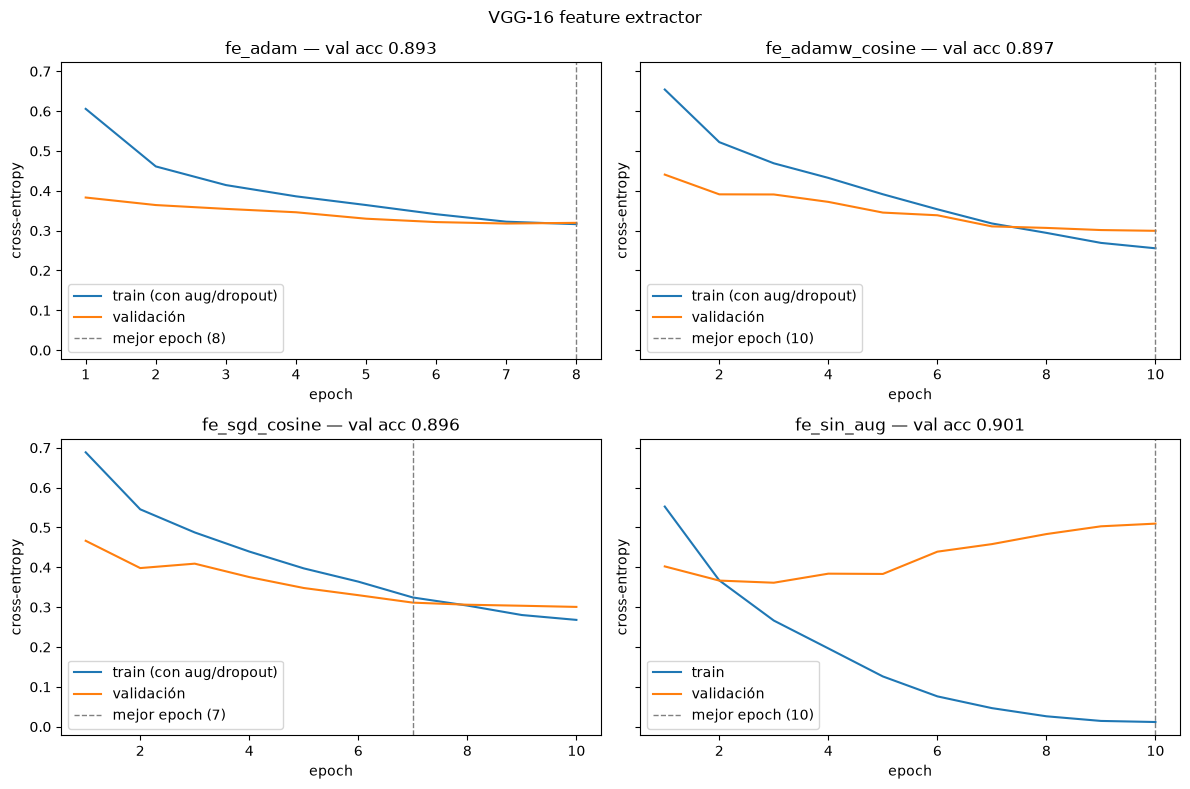

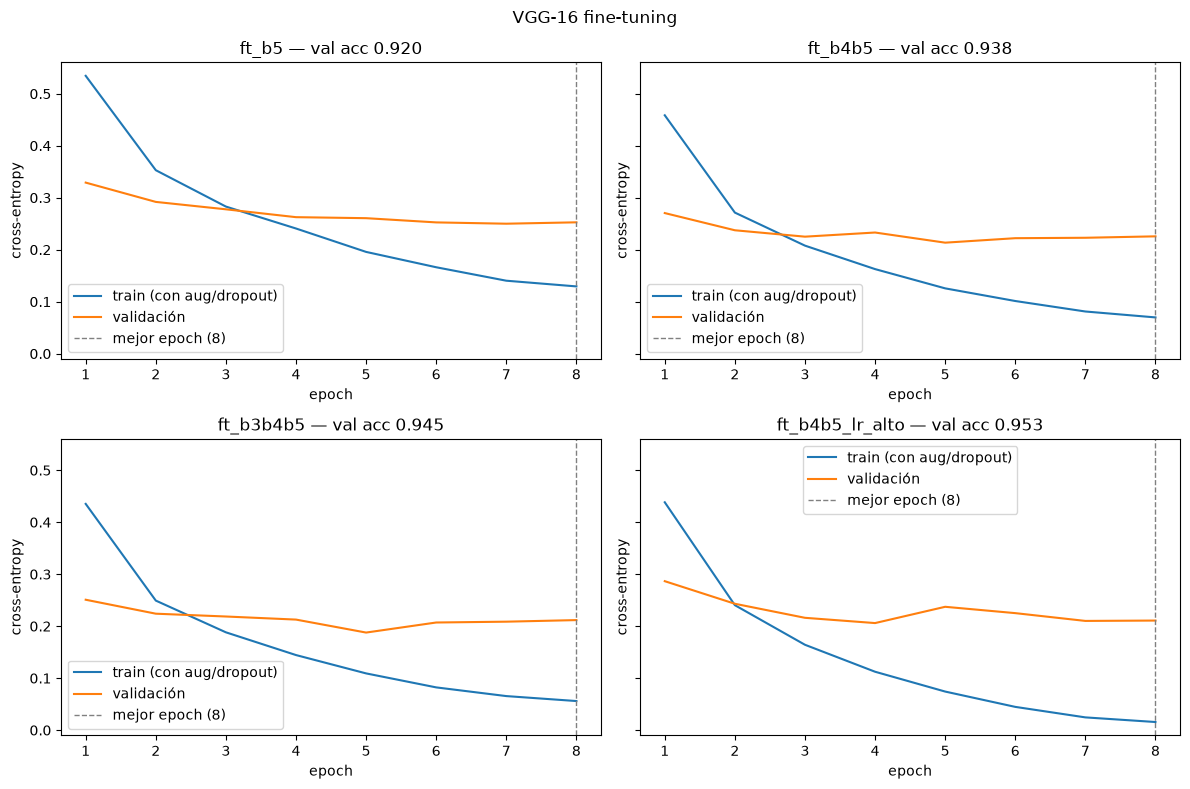

In [19]:
def plot_family(kind, title):
    items = [(n, r) for n, r in RESULTS.items() if r["kind"] == kind]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    for ax, (name, r) in zip(axes.ravel(), items):
        h = r["history"]; ep = range(1, len(h["train_loss"]) + 1)
        ax.plot(ep, h["train_loss"], label="train (con aug/dropout)" if r["config"]["augment"] else "train")
        ax.plot(ep, h["val_loss"], label="validación")
        ax.axvline(r["best_epoch"], color="gray", ls="--", lw=1, label=f"mejor epoch ({r['best_epoch']})")
        ax.set_title(f"{name} — val acc {r['val_best']['acc']:.3f}")
        ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy"); ax.legend()
    plt.suptitle(title); plt.tight_layout(); plt.show()

plot_family("feature_extractor", "VGG-16 feature extractor")
plot_family("fine_tuning", "VGG-16 fine-tuning")

## Accuracy de validación por epoch

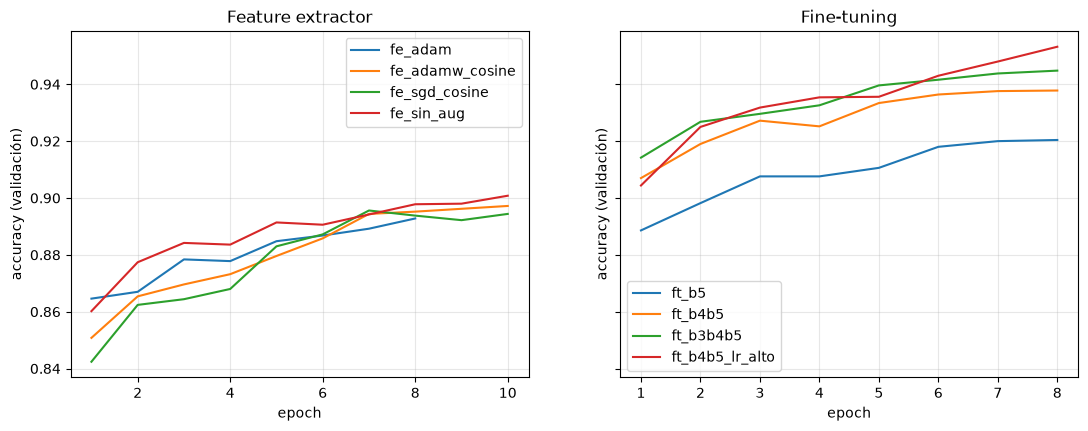

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, kind, t in zip(axes, ["feature_extractor", "fine_tuning"], ["Feature extractor", "Fine-tuning"]):
    for name, r in RESULTS.items():
        if r["kind"] == kind:
            ax.plot(range(1, len(r["history"]["val_acc"]) + 1), r["history"]["val_acc"], label=name)
    ax.set_xlabel("epoch"); ax.set_ylabel("accuracy (validación)"); ax.grid(alpha=0.3); ax.legend(); ax.set_title(t)
plt.show()

## Mejor configuración por modelo

In [21]:
def best_of(kind):
    cands = {k: v for k, v in RESULTS.items() if v["kind"] == kind}
    return max(cands, key=lambda k: cands[k]["val_best"]["f1"])

best_fe, best_ft = best_of("feature_extractor"), best_of("fine_tuning")
print("Mejor feature extractor:", best_fe)
print("Mejor fine-tuning:      ", best_ft)
display(df.loc[[best_fe, best_ft], ["capas congeladas", "val acc", "val F1", "mejor epoch",
                                    "params entrenables", "tiempo total (s)", "mem pico (MB)"]].T)

for name in RESULTS:
    if name not in (best_fe, best_ft):
        Path(f"models/vgg_{name}.pt").unlink(missing_ok=True)

with open("results_vgg.json", "w") as f:
    json.dump({"best": {"feature_extractor": best_fe, "fine_tuning": best_ft}, "results": RESULTS},
              f, indent=2, default=lambda o: list(o) if isinstance(o, tuple) else str(o))

Mejor feature extractor: fe_sin_aug
Mejor fine-tuning:       ft_b4b5_lr_alto


iteración,fe_sin_aug,ft_b4b5_lr_alto
capas congeladas,"features: bloques 1,2,3,4,5 congelados | clasi...","features: bloques 1,2,3 congelados | clasifica..."
val acc,0.9008,0.9532
val F1,0.900959,0.953239
mejor epoch,10,8
params entrenables,119586826,132566026
tiempo total (s),3172.854302,2309.867697
mem pico (MB),2419.459473,2568.000488


In [22]:
def clean_times(r):
    t = np.array(r["history"]["epoch_time"])
    med = np.median(t)
    t_clean = np.where(t > 2 * med, med, t)          # un epoch >2x la mediana = pausa del equipo
    r["history"]["epoch_time_clean"] = t_clean.tolist()
    r["history"]["cum_time_clean"] = np.cumsum(t_clean).tolist()
    r["mean_epoch_time_clean"] = float(t_clean.mean())
    r["total_time_clean"] = float(t_clean.sum())
    r["time_to_best_clean"] = float(np.cumsum(t_clean)[r["best_epoch"] - 1])
    n_out = int((t > 2 * med).sum())
    if n_out: print(f"{r['name']}: {n_out} epoch(s) atípico(s) reemplazado(s) por la mediana ({med:.0f}s)")
    return r

for k in RESULTS:
    RESULTS[k] = clean_times(RESULTS[k])

fe_sgd_cosine: 1 epoch(s) atípico(s) reemplazado(s) por la mediana (176s)
fe_sin_aug: 1 epoch(s) atípico(s) reemplazado(s) por la mediana (188s)


feature_extractor (fe_sin_aug): {'acc': 0.9003, 'precision': 0.9004, 'recall': 0.9003, 'f1': 0.9002}
  Confusiones más frecuentes (real -> predicho): [('dog', 'cat', 97), ('cat', 'dog', 85), ('bird', 'deer', 46), ('truck', 'automobile', 45), ('automobile', 'truck', 38)]
fine_tuning (ft_b4b5_lr_alto): {'acc': 0.9467, 'precision': 0.9469, 'recall': 0.9467, 'f1': 0.9467}
  Confusiones más frecuentes (real -> predicho): [('cat', 'dog', 72), ('dog', 'cat', 54), ('automobile', 'truck', 34), ('bird', 'frog', 20), ('bird', 'cat', 18)]


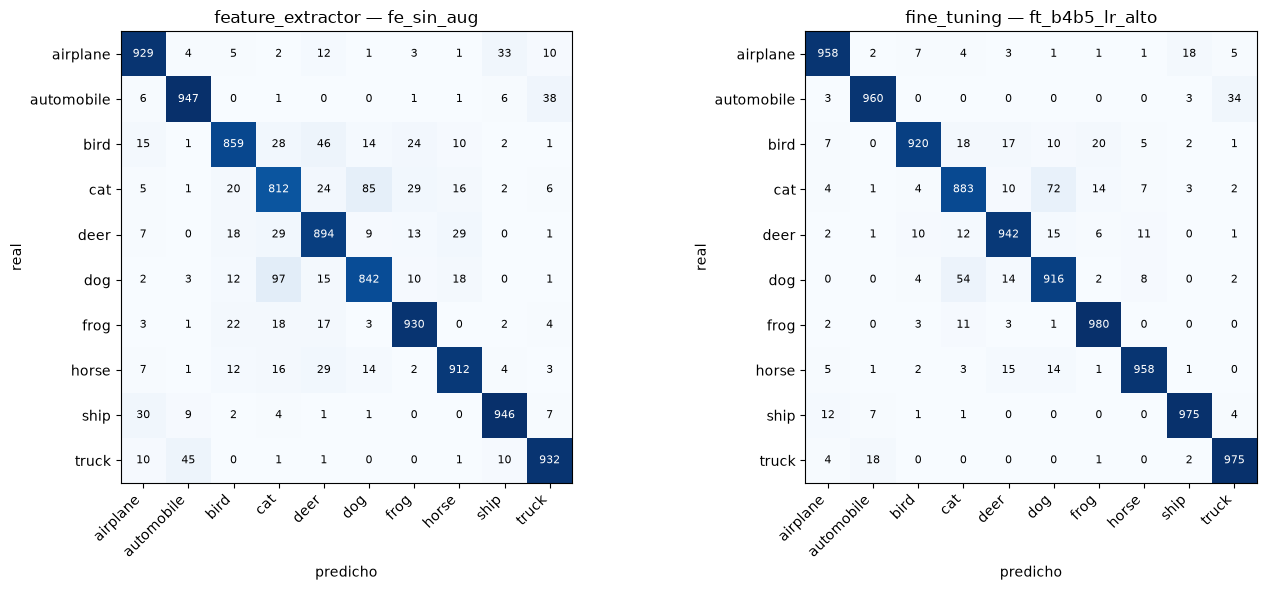

In [23]:
from sklearn.metrics import confusion_matrix

test_ds = datasets.CIFAR10("data", train=False, download=False, transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)

def load_model(name, unfrozen):
    model = build_vgg16(unfrozen=unfrozen)
    missing, unexpected = model.load_state_dict(torch.load(f"models/vgg_{name}.pt"), strict=False)
    assert not unexpected                      
    return model.to(device).eval()

@torch.no_grad()
def predict(model, loader):
    model.eval(); preds, labels = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu()); labels.append(y)
    return torch.cat(preds).numpy(), torch.cat(labels).numpy()

def metrics(labels, preds):
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"acc": float(accuracy_score(labels, preds)), "precision": float(p),
            "recall": float(r), "f1": float(f1)}

def top_confusions(cm, k=5):
    off = cm.copy(); np.fill_diagonal(off, 0)
    flat = np.argsort(-off.ravel())[:k]
    return [(CLASSES[i], CLASSES[j], int(off[i, j])) for i, j in zip(*np.unravel_index(flat, off.shape))]

TEST = {}
for kind, name in [("feature_extractor", best_fe), ("fine_tuning", best_ft)]:
    model = load_model(name, RESULTS[name]["config"]["unfrozen"])
    preds, labels = predict(model, test_loader)
    cm = confusion_matrix(labels, preds)
    TEST[kind] = {"name": name, "metrics": metrics(labels, preds), "cm": cm}
    print(f"{kind} ({name}):", {k: round(v, 4) for k, v in TEST[kind]["metrics"].items()})
    print("  Confusiones más frecuentes (real -> predicho):", top_confusions(cm))
    del model

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (kind, t) in zip(axes, TEST.items()):
    ax.imshow(t["cm"], cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, t["cm"][i, j], ha="center", va="center",
                    color="white" if t["cm"][i, j] > t["cm"].max() / 2 else "black", fontsize=8)
    ax.set_title(f"{kind} — {t['name']}"); ax.set_xlabel("predicho"); ax.set_ylabel("real")
plt.tight_layout(); plt.show()

# Experimento 4.1

In [24]:
print("Balance por clase en train_small:", np.bincount(y_train[idx_train_small]))

def make_loaders_small(augment, batch_size):
    tf = train_tf_aug if augment else eval_tf
    full = datasets.CIFAR10("data", train=True, download=False, transform=tf)
    return (DataLoader(Subset(full, idx_train_small), batch_size=batch_size, shuffle=True, num_workers=0),
            DataLoader(DSETS[False]["val"], batch_size=128, shuffle=False, num_workers=0))

def run_small(best_name):
    global make_loaders
    cfg_ = copy.deepcopy(RESULTS[best_name]["config"])
    name = f"small_{best_name}"
    orig = make_loaders
    make_loaders = make_loaders_small          
    try:
        r = run_experiment(name, cfg_)
    finally:
        make_loaders = orig
    return name, clean_times(r)

SMALL = {}
for kind, best_name in [("feature_extractor", best_fe), ("fine_tuning", best_ft)]:
    name, r = run_small(best_name)
    model = load_model(name, r["config"]["unfrozen"])
    preds, labels = predict(model, test_loader)
    SMALL[kind] = {"name": name, "run": r, "metrics": metrics(labels, preds),
                   "cm": confusion_matrix(labels, preds)}
    del model

rows = []
for kind in TEST:
    full, small = TEST[kind]["metrics"], SMALL[kind]["metrics"]
    rows.append({"modelo": kind,
                 "acc 100%": full["acc"], "acc 10%": small["acc"], "Δ acc": small["acc"] - full["acc"],
                 "F1 100%": full["f1"], "F1 10%": small["f1"], "Δ F1": small["f1"] - full["f1"],
                 "tiempo 10% (s)": SMALL[kind]["run"]["total_time_clean"]})
df41 = pd.DataFrame(rows).set_index("modelo")
display(df41.round(4))

out = {
    "best": {"feature_extractor": best_fe, "fine_tuning": best_ft},
    "iterations": RESULTS,
    "test_100": {k: {"name": v["name"], "metrics": v["metrics"], "cm": v["cm"].tolist()} for k, v in TEST.items()},
    "test_10": {k: {"name": v["name"], "metrics": v["metrics"], "cm": v["cm"].tolist(),
                    "run": v["run"]} for k, v in SMALL.items()},
}
with open("results_vgg_final.json", "w") as f:
    json.dump(out, f, indent=2)

Balance por clase en train_small: [450 450 450 450 450 450 450 450 450 450]
[small_fe_sin_aug] ep 01/10 | train 0.8414 | val 0.6016 | acc 0.7864 | f1 0.7850 | 19.7s
[small_fe_sin_aug] ep 02/10 | train 0.3880 | val 0.6157 | acc 0.7982 | f1 0.7988 | 18.3s
[small_fe_sin_aug] ep 03/10 | train 0.2202 | val 0.5585 | acc 0.8326 | f1 0.8338 | 18.4s
[small_fe_sin_aug] ep 04/10 | train 0.1026 | val 0.7127 | acc 0.8190 | f1 0.8208 | 18.1s
[small_fe_sin_aug] ep 05/10 | train 0.0531 | val 0.7409 | acc 0.8298 | f1 0.8286 | 3304.6s
[small_fe_sin_aug] ep 06/10 | train 0.0358 | val 0.7522 | acc 0.8330 | f1 0.8339 | 45.3s
[small_fe_sin_aug] ep 07/10 | train 0.0160 | val 0.7045 | acc 0.8476 | f1 0.8479 | 18.3s
[small_fe_sin_aug] ep 08/10 | train 0.0090 | val 0.6976 | acc 0.8476 | f1 0.8478 | 18.2s
[small_fe_sin_aug] ep 09/10 | train 0.0043 | val 0.7015 | acc 0.8486 | f1 0.8488 | 18.3s
[small_fe_sin_aug] ep 10/10 | train 0.0036 | val 0.7006 | acc 0.8502 | f1 0.8502 | 18.3s
small_fe_sin_aug: 2 epoch(s) atí

,acc 100%,acc 10%,Δ acc,F1 100%,F1 10%,Δ F1,tiempo 10% (s)
modelo,,,,,,,
feature_extractor,0.9003,0.8431,-0.0572,0.9002,0.843,-0.0573,184.3603
fine_tuning,0.9467,0.8982,-0.0485,0.9467,0.898,-0.0487,220.0460
